# Presence of repository

In [1]:
import sys
sys.path.append("../")

import pandas as pd
from src.repo_utils import RepoStatus

In [2]:
df_repo_presence_assessment = pd.read_csv("../data/8_repo_assessment/full_dataset_LLM_pred.csv")
df_repos_clone_assessment = pd.read_csv("../data/8_repo_assessment/full_dataset_with_repo_content.csv")
df_repo_content_assessment = pd.read_csv("../data/8_repo_assessment/full_dataset_with_repo_content_ok_pred.csv")

In [3]:
df_repo_presence_assessment = df_repo_presence_assessment.drop_duplicates(subset="PMID", keep="first")

In [4]:
len(df_repo_presence_assessment)

5251

In [5]:
cols_to_add = ["PMID", "repo_content", "repo_status"]

df_repo_presence_assessment = df_repo_presence_assessment.merge(
    df_repos_clone_assessment[cols_to_add],
    on="PMID",
    how="left"
)

df_repo_presence_assessment = df_repo_presence_assessment.drop_duplicates(subset="PMID", keep="first")

In [6]:
len(df_repo_presence_assessment)

5251

In [7]:
cols_to_add = [
    'PMID', 'is_empty_pred',
    'contains_readme_pred', 'readme_purpose_and_outputs_pred',
    'contains_requirements_pred', 'requirements_dependency_versions_pred',
    'contains_license_pred', 'sufficient_code_documentation_pred',
    'is_modular_and_structured_pred', 'implements_tests_pred',
    'fixes_seed_if_stochastic_pred', 'hardware_requirements_pred',
    'contains_link_to_paper_pred', 'contains_citation_pred',
    'includes_data_or_sample_pred', 'comments_and_explanations_pred'
]

df_repo_presence_assessment = df_repo_presence_assessment.merge(
    df_repo_content_assessment[cols_to_add],
    on="PMID",
    how="left"
)

df_repo_presence_assessment = df_repo_presence_assessment.drop_duplicates(subset="PMID", keep="first")

In [8]:
len(df_repo_presence_assessment)


5251

In [9]:
df_repo_presence_assessment["LLM_paper_assessment"].value_counts(normalize=True)

LLM_paper_assessment
True     0.749572
False    0.250428
Name: proportion, dtype: float64

In [10]:
df_in_scope = df_repo_presence_assessment[df_repo_presence_assessment["LLM_paper_assessment"]]
len(df_in_scope)

3936

In [11]:
df_in_scope["LLM_url"].value_counts(normalize=True, dropna=False)

LLM_url
NaN                                                                                                 0.871189
Appendix                                                                                            0.022358
https://github.com/Google-Health/google-health                                                      0.000508
https://github.com/Agleason1/Neonatal-Pose-AI--Sedation-and-Cerebral-Dysfunction                    0.000508
https://github.com/htx-r/Reproduce-results-from-papers                                              0.000508
                                                                                                      ...   
https://github.com/WenjuanW/Risk_Prediction_of_Post-Stroke_30-day_Mortality_SSNAP_and_RiksStroke    0.000254
https://github.com/dgbrow02/esbl_prediction_code                                                    0.000254
https://git.rwth-aachen.de/workgroup-lara/multiclass_segmentation_pancreatic_cancer                 0.000254
https://git

In [12]:
df_in_scope["LLM_url"].value_counts()

LLM_url
Appendix                                                                                            88
https://github.com/rutgervandeleur/ecgxai                                                            2
https://github.com/ohdsi-studies/Covid19PredictionStudies                                            2
https://github.com/pennsignals/eol-onc                                                               2
https://github.com/KosorokLab/CovidIBDRiskCalc                                                       2
                                                                                                    ..
https://github.com/ohdsi-studies/lungCancerPrognostic                                                1
https://github.com/WenjuanW/Risk_Prediction_of_Post-Stroke_30-day_Mortality_SSNAP_and_RiksStroke     1
https://github.com/dgbrow02/esbl_prediction_code                                                     1
https://git.rwth-aachen.de/workgroup-lara/multiclass_segmentation

In [13]:
import pandas as pd
from urllib.parse import urlparse

# Exclude NA/empty and appendix placeholders
urls = (
    df_in_scope["LLM_url"]
    .fillna("")
    .astype(str)
    .str.strip()
)
urls = urls[~urls.isin(["", "Appendix", "Appendi", "<NA>"])]

def extract_domain(url):
    # Handle malformed or plain text entries gracefully
    if not (url.startswith("http://") or url.startswith("https://")):
        url = "http://" + url  # helps urlparse handle it
    try:
        parsed = urlparse(url)
        return parsed.netloc
    except Exception:
        return "<invalid>"

domain_series = urls.apply(extract_domain)

# Count proportions by domain
domain_counts = (
    domain_series.value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
    .rename(columns={"LLM_url": "domain"})
)

print(domain_counts)

                           domain  proportion
0                      github.com    0.832936
1                         doi.org    0.064439
2                          osf.io    0.033413
3                      gitlab.com    0.011933
4                 www.synapse.org    0.004773
5                      zenodo.org    0.004773
6                   qdiabetes.org    0.004773
7                sdr.stanford.edu    0.002387
8                    duke.box.com    0.002387
9                   gitlab.lrz.de    0.002387
10                  www.qrisk.org    0.002387
11                 qmortality.org    0.002387
12           biostat.app.vumc.org    0.002387
13                 huggingface.co    0.002387
14             git.rwth-aachen.de    0.002387
15          data.unityimaging.net    0.002387
16    gitlab.developers.cam.ac.uk    0.002387
17                picudatalab.com    0.002387
18                     dx.doi.org    0.002387
19  medical-physics-usz.github.io    0.002387
20         www.rama.mahidol.ac.th 

/var/folders/h6/z36012w55gz3qplddg4wtlf80000gn/T/ipykernel_16582/3860729139.py:37: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




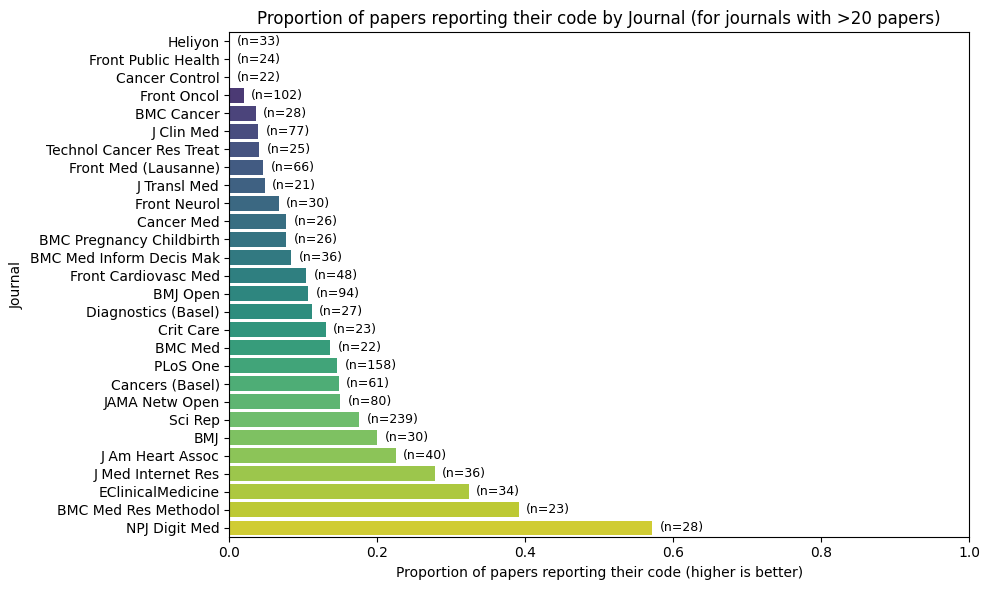

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute ratio of non-empty LLM_url per Journal/Book
counts = df_in_scope["Journal/Book"].value_counts()
valid_journals = counts[counts > 20].index

reported_mask = (
    df_in_scope["repo_status"].isin(
        [RepoStatus.OK.value, RepoStatus.NOT_SUPPORTED.value]
    )
    | (df_in_scope["LLM_url"] == "Appendix")
)

ratio_df = (
    df_in_scope[df_in_scope["Journal/Book"].isin(valid_journals)]
    .assign(is_reported=reported_mask)
    .groupby("Journal/Book", dropna=False)["is_reported"]
    .mean()  # proportion reporting
    .reset_index(name="reported_ratio")
)

support_df = (
    df_in_scope[df_in_scope["Journal/Book"].isin(valid_journals)]
    .groupby("Journal/Book")
    .size()
    .reset_index(name="support")
)

# Sort ascending (increasing order of proportion reporting)
ratio_df = ratio_df.sort_values("reported_ratio", ascending=True)
ratio_df = ratio_df.merge(support_df, on="Journal/Book", how="left")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ratio_df,
    x="reported_ratio",
    y="Journal/Book",
    palette="viridis"
)
ax = plt.gca()

for i, row in ratio_df.iterrows():
    ax.text(
        row["reported_ratio"] + 0.01,  # slightly to the right of the bar
        i,
        f"(n={row['support']})",
        va="center",
        fontsize=9,
        color="black"
    )
plt.xlabel("Proportion of papers reporting their code (higher is better)")
plt.ylabel("Journal")
plt.title("Proportion of papers reporting their code by Journal (for journals with >20 papers)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [27]:
df_repo_presence_assessment["LLM_paper_assessment"]

0        True
1        True
2        True
3        True
4       False
        ...  
5247    False
5248    False
5249     True
5250     True
5251     True
Name: LLM_paper_assessment, Length: 5251, dtype: bool

In [ ]:
def map_repo_label(row):
    if not row["LLM_paper_assessment"]:
        return None
    
    status = row["repo_status"]
    llm_url = row["LLM_url"]

    # 1. Repository successfully shared
    if status == RepoStatus.OK.value or status == RepoStatus.EMPTY.value or status == RepoStatus.INACCESSIBLE.value or status == RepoStatus.NOT_SUPPORTED.value:
        return "Repository Shared"

    # 2. Code shared in appendix (no repo clone attempt)
    if pd.isna(status):
        if isinstance(llm_url, str) and llm_url.strip().lower() == "appendix":
            return "Code Shared in Appendix"

    # 3. All remaining cases
    return "No Code Shared"

In [16]:
df_repo_presence_assessment["repo_sharing_label"] = (
    df_repo_presence_assessment.apply(map_repo_label, axis=1)
)

In [17]:
counts = (
    df_repo_presence_assessment["repo_sharing_label"]
    .value_counts()
    .sort_values(ascending=False)
)

In [18]:
import plotly.express as px

fig = px.pie(
    names=counts.index,
    values=counts.values,
    title=f"Code Sharing Status Across Publications (n={len(df_repo_presence_assessment)})",
)

fig.update_traces(
    textinfo="percent",
    textposition="inside",
    insidetextorientation="auto"
)

fig.update_layout(
    width=800,
    height=800,
    showlegend=True
)

fig.show()

In [19]:
def map_code_sharing_practice(row):
    status = row["repo_status"]
    llm_url = row["LLM_url"]

    # Code shared via repository (with outcomes)
    if status == "ok":
        return "Non Empty Repository"
    elif status == "empty" or row["is_empty_pred"]==True:
        return "Empty Repository"
    elif status == "inaccessible":
        return "Repository Can't Be Accessed"
    elif status == "not_supported":
        return "Repository Provider Not Supported"

    # Code shared in appendix (no repo)
    if pd.isna(status):
        if isinstance(llm_url, str) and llm_url.strip().lower() == "appendix":
            return "Code Shared in Appendix"

    # Everything else: exclude from analysis
    return None

In [20]:
df_repo_presence_assessment["code_sharing_practice"] = (
    df_repo_presence_assessment.apply(map_code_sharing_practice, axis=1)
)

In [21]:
counts = (
    df_repo_presence_assessment["code_sharing_practice"]
    .dropna()
    .value_counts()
)

In [22]:
import plotly.express as px

fig = px.pie(
    names=counts.index,
    values=counts.values,
    title=f"Code Sharing Status Across Publications (n={counts.sum()})",
)

fig.update_traces(
    textinfo="percent",
    textposition="inside",
    insidetextorientation="auto"
)

fig.update_layout(
    width=800,
    height=800,
    showlegend=True
)

fig.show()

In [19]:
count_no_url_or_empty_or_inaccessible = len(
    df_repo_presence_assessment[
        (df_repo_presence_assessment["LLM_url"].isna()) |
        (df_repo_presence_assessment["repo_status"] == "empty") |
        (df_repo_presence_assessment["repo_status"] == "inaccessible")
    ]
)
print(f"Number of rows where LLM_url is NaN or repo_status is 'empty' or 'inaccessible': {count_no_url_or_empty_or_inaccessible}/{len(df_repo_presence_assessment)}")
print(f"Percentage: {100 - count_no_url_or_empty_or_inaccessible / len(df_repo_presence_assessment) * 100:.2f}%")

Number of rows where LLM_url is NaN or repo_status is 'empty' or 'inaccessible': 4831/5298
Percentage: 8.81%


In [35]:
df_repo_presence_assessment.columns

Index(['PMID', 'Title', 'Authors', 'Citation', 'First Author', 'Journal/Book',
       'Publication Year', 'Create Date', 'PMCID', 'NIHMS ID', 'DOI',
       'full_text', 'LLM_paper_assessment', 'LLM_reason', 'LLM_url',
       'repo_content', 'repo_status', 'is_empty_pred', 'contains_readme_pred',
       'readme_purpose_and_outputs_pred', 'contains_requirements_pred',
       'requirements_dependency_versions_pred', 'contains_license_pred',
       'sufficient_code_documentation_pred', 'is_modular_and_structured_pred',
       'implements_tests_pred', 'fixes_seed_if_stochastic_pred',
       'hardware_requirements_pred', 'contains_link_to_paper_pred',
       'contains_citation_pred', 'includes_data_or_sample_pred',
       'comments_and_explanations_pred', 'repo_sharing_label',
       'code_sharing_practice'],
      dtype='object')

In [76]:
# ------------------------------------------------------------
# 1. Select prediction columns
# ------------------------------------------------------------
pred_cols = [
    c for c in df_repo_content_assessment.columns
    if c.endswith("_pred") and c != "comments_and_explanations_pred"
]

base_pred_cols = [
    c for c in pred_cols
    if c not in [
        "contains_readme_pred",
        "readme_purpose_and_outputs_pred",
        "contains_requirements_pred",
        "requirements_dependency_versions_pred",
    ]
]

df = df_repo_content_assessment

# Total number of evaluated repositories (global denominator)
N = len(df)

# ------------------------------------------------------------
# 2. Build plotting rows
# ------------------------------------------------------------
plot_rows = []

# Regular criteria (single bar, percent of all repos)
for col in base_pred_cols:
    evaluated = df[col].notna().sum()
    if evaluated == 0:
        continue

    pct_true = 100 * df.loc[df[col].notna(), col].astype(bool).sum() / N

    plot_rows.append({
        "criterion": col.replace("_pred", ""),
        "value": pct_true,
        "segment": "True",
        "text": ""
    })

# ------------------------------------------------------------
# README conditional bar (corrected)
# ------------------------------------------------------------
readme_present = df["contains_readme_pred"] == True

pct_readme_present = 100 * readme_present.sum() / N

readme_complete = (
    readme_present
    & (df["readme_purpose_and_outputs_pred"] == True)
)

readme_incomplete = (
    readme_present
    & (df["readme_purpose_and_outputs_pred"] == False)
)

plot_rows.extend([
    {
        "criterion": "contains_readme",
        "value": 100 * readme_incomplete.sum() / N,
        "segment": "Incomplete README",
        "text": "Incomplete"
    },
    {
        "criterion": "contains_readme",
        "value": 100 * readme_complete.sum() / N,
        "segment": "Purpose & outputs",
        "text": "Complete"
    }
])

# ------------------------------------------------------------
# Requirements conditional bar (corrected)
# ------------------------------------------------------------
req_present = df["contains_requirements_pred"] == True

req_complete = (
    req_present
    & (df["requirements_dependency_versions_pred"] == True)
)

req_incomplete = (
    req_present
    & (df["requirements_dependency_versions_pred"] == False)
)

plot_rows.extend([
    {
        "criterion": "contains_requirements",
        "value": 100 * req_incomplete.sum() / N,
        "segment": "Incomplete dependencies",
        "text": "Not versioned"
    },
    {
        "criterion": "contains_requirements",
        "value": 100 * req_complete.sum() / N,
        "segment": "Versioned dependencies",
        "text": "Versioned"
    }
])

plot_df = pd.DataFrame(plot_rows)

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
fig = px.bar(
    plot_df,
    x="criterion",
    y="value",
    color="segment",
    text="text",
    title=f"Predicted Repository Documentation Practices (n={len(df)})",
    labels={
        "criterion": "Repository Quality Criterion",
        "value": "Percentage of Repositories (%)"
    },
    color_discrete_map={
        "True": "#636EFA",
        "Incomplete README": "#EF553B",
        "Purpose & outputs": "#00CC96",
        "Incomplete dependencies": "#EF553B",
        "Versioned dependencies": "#00CC96",
    }
)

pretty = lambda s: s.replace("_", " ").title()

fig.update_xaxes(
    tickvals=plot_df["criterion"].unique(),
    ticktext=[pretty(c) for c in plot_df["criterion"].unique()],
    tickangle=45
)

fig.update_traces(
    textposition="inside",
    insidetextanchor="middle"
)

fig.update_layout(
    barmode="stack",
    width=1100,
    height=500,
    showlegend=False,
    yaxis_range=[0, 100]
)

fig.show()

In [47]:
df_repo_content_assessment[pred_cols].value_counts(dropna=False)

is_empty_pred
False            300
NaN               34
True              18
Name: count, dtype: int64

In [52]:
df_repo_content_assessment[df_repo_content_assessment['is_empty_pred'].isna()][["repo_status", "generation", "is_empty_pred"]]

,repo_status,generation,is_empty_pred
26,ok,NaN,NaN
44,ok,NaN,NaN
46,ok,NaN,NaN
47,ok,NaN,NaN
48,ok,NaN,NaN
57,ok,NaN,NaN
59,ok,NaN,NaN
60,ok,NaN,NaN
63,ok,NaN,NaN
76,ok,NaN,NaN
